In [3]:
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
np.random.seed(2)

X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]]) #shape (1,20) 1 features, 20 data point
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1]) # real label

# extended data 
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0) # để đưa z = wo + w1x về z = w.T@X (1*d)*(d*N) -> 1*N cho 1 data point

In [4]:
def sigmoid(s) :
    return 1/(1+np.exp(-s))

In [27]:
def logistic_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]
    count = 0
    N = X.shape[1]
    d = X.shape[0]
    check_w_after = 20
    while count <= max_count:
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:,i].reshape(d,1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi-zi)*xi
            count += 1
            if count % check_w_after == 0:
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w
d = X.shape[0]
w_init = np.random.randn(d,1)
eta = 0.05
w = logistic_regression(X, y, w_init,eta)
z = w[-1].T @ X
print(sigmoid(z))
y_pred = (sigmoid(z) >= 0.5).astype(int)
y_pred = y_pred.reshape(-1)
print(w[-1])
print(y_pred)
    


[[0.03494514 0.0509129  0.07362035 0.10533145 0.14851198 0.20533165
  0.20533165 0.27682276 0.36187036 0.45655136 0.55447972 0.64835333
  0.73200723 0.80184279 0.8987939  0.92936109 0.95119738 0.96652665
  0.97715651 0.98946043]]
[[-4.10444856]
 [ 1.57208583]]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


Các hàm cần thiết cho logistic regression

In [24]:
from sklearn.metrics import accuracy_score
print(y.shape, y_pred.shape)
print (f"Accuracy of model: {100*accuracy_score(y, y_pred)}")
print(sigmoid(np.dot(w[-1].T, X)))

(20,) (20,)
Accuracy of model: 80.0
[[0.03499944 0.05108722 0.0740028  0.10604859 0.14972751 0.20722642
  0.20722642 0.27954667 0.36547074 0.4609092  0.55930238 0.65324765
  0.73659777 0.8058668  0.90144661 0.9314013  0.95272888 0.9676559
  0.9779783  0.98988418]]


Biểu diễn kết quả trên đồ thị:

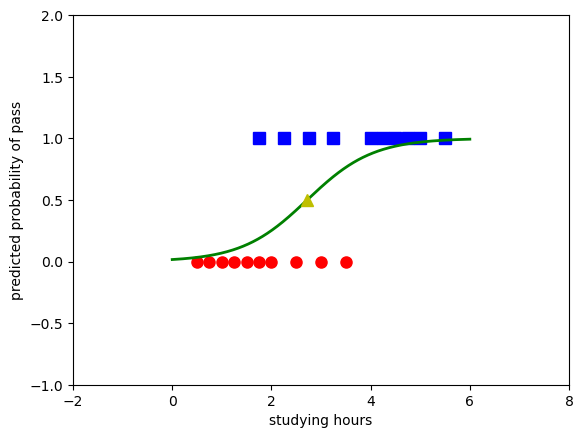

In [34]:
X0 = X[1, np.where(y == 0)][0] # idx = np.where(y==0)[0] X0 = X[1, idx]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', ms = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


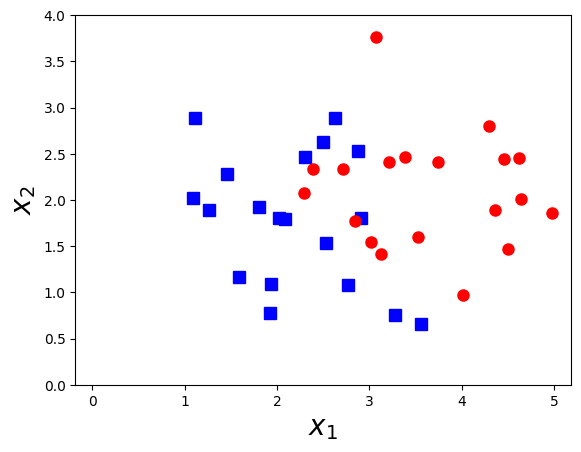

In [6]:
from scipy.spatial.distance import cdist

np.random.seed(22)

# Khởi tạo trung tâm của 2 cụm dữ liệu
means = [[2, 2], [4, 2]]
# Ma trận hiệp phương sai (độ phân tán của dữ liệu)
cov = [[.7, 0], [0, .7]]
N = 20

# Tạo dữ liệu ngẫu nhiên cho cụm 0 (X0) và cụm 1 (X1)
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)

# Vẽ dữ liệu lên đồ thị
plt.plot(X0[:, 0], X0[:, 1], 'bs', markersize = 8, alpha = 1)
plt.plot(X1[:, 0], X1[:, 1], 'ro', markersize = 8, alpha = 1)
plt.axis('equal')
plt.ylim(0, 4)
plt.xlim(0, 5)

# Định dạng đồ thị
plt.xlabel('$x_1$', fontsize = 20)
plt.ylabel('$x_2$', fontsize = 20)
plt.show()

Huấn luyện mô hình Logistic regression giải quyết bài toán phân loại nhị phân

In [10]:
# Load data từ file csv
data = pd.read_csv('data/raw/dataset.csv').values
N, d = data.shape
x = data[:, 0:d-1].reshape(-1, d-1)
y = data[:, 2].reshape(-1, 1)

Text(0, 0.5, 'kinh nghiệm (năm)')

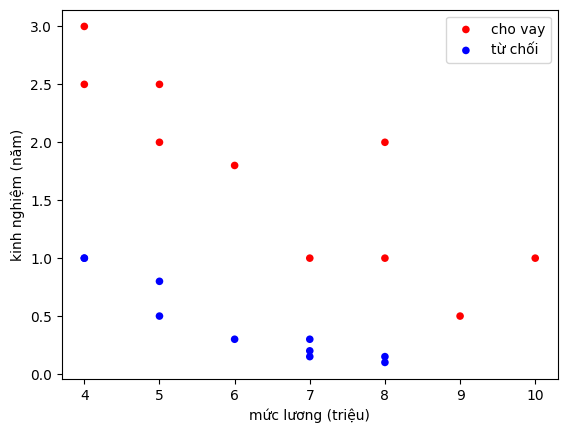

In [11]:
# Vẽ data bằng scatter
x_cho_vay = x[y[:,0]==1]
x_tu_choi = x[y[:,0]==0]

plt.scatter(x_cho_vay[:, 0], x_cho_vay[:, 1], c='red', edgecolors='none', s=30, label='cho vay')
plt.scatter(x_tu_choi[:, 0], x_tu_choi[:, 1], c='blue', edgecolors='none', s=30, label='từ chối')
plt.legend(loc=1)
plt.xlabel('mức lương (triệu)')
plt.ylabel('kinh nghiệm (năm)')

In [4]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. Chuẩn bị dữ liệu (Lưu ý: Không cần thêm hàng số 1 nữa)
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# sklearn yêu cầu dữ liệu X phải ở dạng (số_lượng_mẫu, số_đặc_trưng). 
# Do đó ta phải chuyển vị (transpose) ma trận X ban đầu.
X = X.T 

# 2. Khởi tạo mô hình
model = LogisticRegression()

# 3. Huấn luyện (Train) mô hình - Hàm fit() sẽ tự động làm mọi vòng lặp SGD bên trong
model.fit(X, y)
# 4. In ra kết quả trọng số
print("Trọng số (w1):", model.coef_)
print("Bias (w0):", model.intercept_)


Trọng số (w1): [[1.14881183]]
Bias (w0): [-3.14004565]
